<a href="https://colab.research.google.com/github/Mansik-04/assignments/blob/main/linear%20regg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What does R-squared represent in a regression model
R² (coefficient of determination) is the proportion of variance in the dependent variable explained by the independent variables. Ranges 0–1; higher value → model explains more variance.

What are the assumptions of linear regression
Linearity, independence of errors, homoscedasticity (constant variance of residuals), normality of residuals, no perfect multicollinearity, and correct model specification.

Difference between R-squared and Adjusted R-squared
R² always increases (or stays same) when adding predictors. Adjusted R² penalizes adding predictors that don’t improve the model, adjusting for number of features and sample size.

Why do we use Mean Squared Error (MSE)
MSE measures average squared difference between actual and predicted values — useful for optimization (differentiable) and penalizes larger errors more strongly.

What does an Adjusted R-squared value of 0.85 indicate
About 85% of the variance in the response is explained by the model after adjusting for number of predictors — indicates strong explanatory power (given assumptions hold).

How do we check for normality of residuals in linear regression
Use histogram of residuals, Q-Q plot, and statistical tests (e.g., Shapiro–Wilk). For large samples minor deviations are less concerning.

What is multicollinearity, and how does it impact regression
Multicollinearity: predictors highly correlated with each other. It inflates coefficient standard errors, makes estimates unstable and coefficient interpretation unreliable.

What is Mean Absolute Error (MAE)
MAE is average absolute difference between actual and predicted values. Less sensitive to outliers than MSE.

What are the benefits of using an ML pipeline
Reproducibility, encapsulation of preprocessing + model, prevents data leakage (fit transforms only on training set during CV), easier experimentation, cleaner code.

Why is RMSE considered more interpretable than MSE
RMSE is square root of MSE and has the same units as the target variable, making error magnitude easier to interpret.

What is pickling in Python, and how is it useful in ML
Pickling serializes Python objects to disk (via pickle) so trained models or pipelines can be saved and later loaded for prediction.

What does a high R-squared value mean
Model explains a large proportion of variance in the target; but high R² doesn’t guarantee causality, correct specification, or absence of overfitting.

What happens if linear regression assumptions are violated
Estimates might be biased (if specification error), inefficient, or hypothesis tests may be invalid. Remedies vary by violated assumption.

How can we address multicollinearity in regression
Remove or combine correlated features, use PCA, use regularization (Ridge, Lasso), or collect more data.

How can feature selection improve model performance in regression analysis
Reduces overfitting, reduces variance, improves interpretability, speeds up training, and can improve generalization.

How is Adjusted R-squared calculated
Adjusted R² = 1 − [(1−R²)*(n−1)/(n−p−1)] where n = sample size, p = number of predictors.

Why is MSE sensitive to outliers
Because errors are squared, large errors are amplified more than small ones.

What is the role of homoscedasticity in linear regression
Homoscedasticity (constant residual variance) ensures unbiased, efficient OLS estimators and valid standard errors; heteroscedasticity invalidates some test statistics.

What is Root Mean Squared Error (RMSE)
RMSE = sqrt(MSE). It’s the square root of average squared errors and in same units as the target.

Why is pickling considered risky
Pickle can execute arbitrary code on load, which is a security risk if loading untrusted files. Also pickled objects can break across Python/library versions.

What alternatives exist to pickling for saving ML models
joblib (for scikit-learn objects), model-specific formats (e.g., sklearn via joblib, TensorFlow SavedModel, ONNX), export to PMML, or saving model parameters to JSON/csv.

What is heteroscedasticity, and why is it a problem
Heteroscedasticity means non-constant variance of errors across levels of predictors. It leads to inefficient OLS estimates and biased standard errors, making hypothesis tests unreliable.

How can interaction terms enhance a regression model's predictive power?
Interaction terms model the situation where the effect of one predictor depends on another. They capture conditional relationships and can improve fit when variables interact.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import pickle
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
sns.set_style("whitegrid")
%matplotlib inline


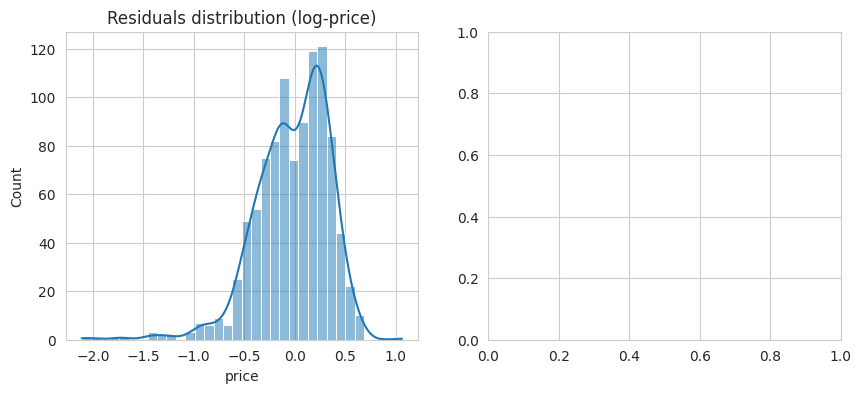

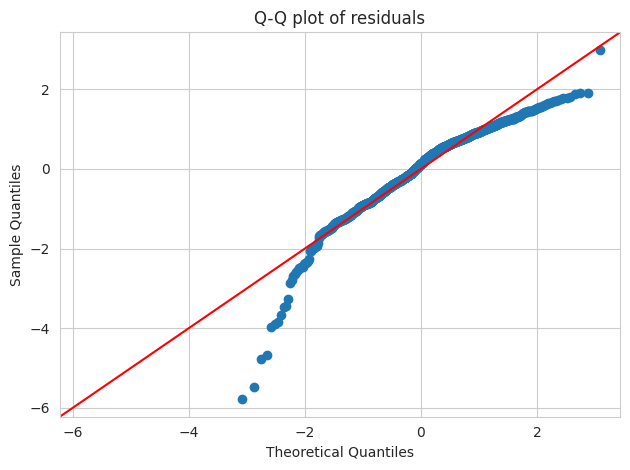

In [2]:
#ques 1
# Cell 1
df = sns.load_dataset("diamonds").dropna()
# select subset of numeric features and log-transform price (because price is skewed)
df = df.sample(5000, random_state=42)  # reduce for speed
X = pd.get_dummies(df[['cut','color','clarity']], drop_first=True)
X['carat'] = df['carat']
y = np.log(df['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
lr = LinearRegression().fit(X_train, y_train)
pred = lr.predict(X_test)
residuals = y_test - pred

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Residuals distribution (log-price)")

plt.subplot(1,2,2)
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q plot of residuals")
plt.tight_layout()
plt.show()


In [3]:
#ques 2
# Cell 2
# Use Boston-like synthetic (sklearn removed Boston); use diamonds sample from above
mse = mean_squared_error(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mse)
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


MSE: 0.1310
MAE: 0.2826
RMSE: 0.3620


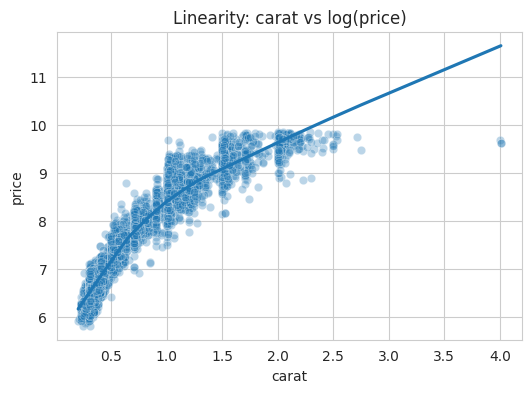

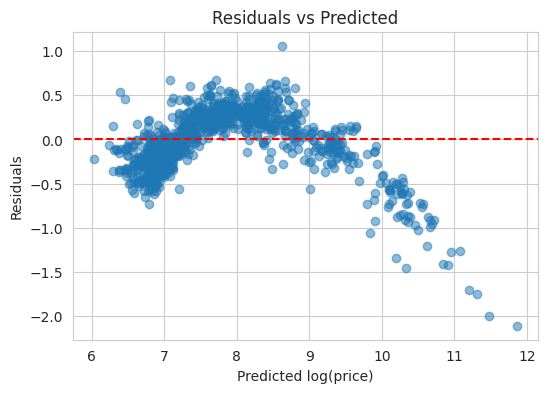

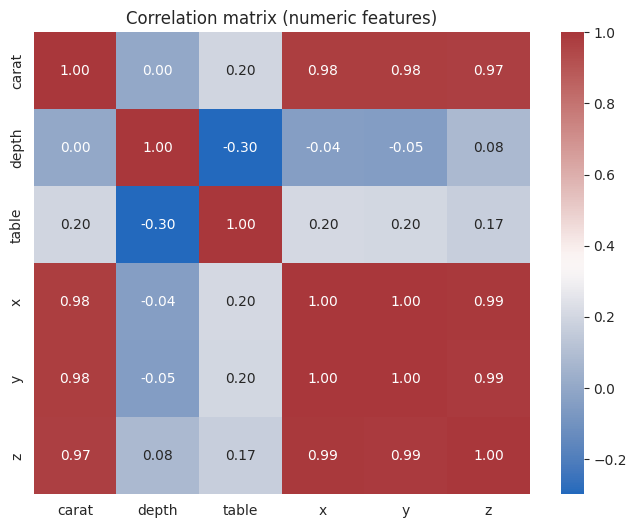

In [4]:
#ques 3
# Cell 3
# Linearity: plot carat vs log(price) with regression line
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['carat'], y=np.log(df['price']), alpha=0.3)
sns.regplot(x=df['carat'], y=np.log(df['price']), scatter=False, lowess=True)
plt.title("Linearity: carat vs log(price)")
plt.show()

# Residuals vs predicted (homoscedasticity)
plt.figure(figsize=(6,4))
plt.scatter(pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted log(price)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# Correlation matrix for numeric features
numeric = df.select_dtypes(include=[np.number]).drop(columns=['price'])
corr = numeric.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='vlag')
plt.title("Correlation matrix (numeric features)")
plt.show()


In [5]:
#ques 4
# Synthetic dataset
from sklearn.datasets import make_regression
X_syn, y_syn = make_regression(n_samples=500, n_features=5, noise=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_syn, y_syn, test_size=0.2, random_state=42)

pipelines = {
    'LR': Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    'Ridge': Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))])
}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    print(name, "R2:", r2_score(y_test, preds), "RMSE:", np.sqrt(mean_squared_error(y_test, preds)))


LR R2: 0.9910587469991373 RMSE: 10.311401479279889
Ridge R2: 0.9910850131968718 RMSE: 10.296244738299128


In [6]:
#ques 5
# Use 'tips' dataset total_bill -> tip
tips = sns.load_dataset("tips")
X = tips[['total_bill']].values
y = tips['tip'].values
lr = LinearRegression().fit(X, y)
print("Coefficient:", lr.coef_[0])
print("Intercept:", lr.intercept_)
print("R-squared:", lr.score(X, y))


Coefficient: 0.10502451738435337
Intercept: 0.9202696135546731
R-squared: 0.45661658635167657


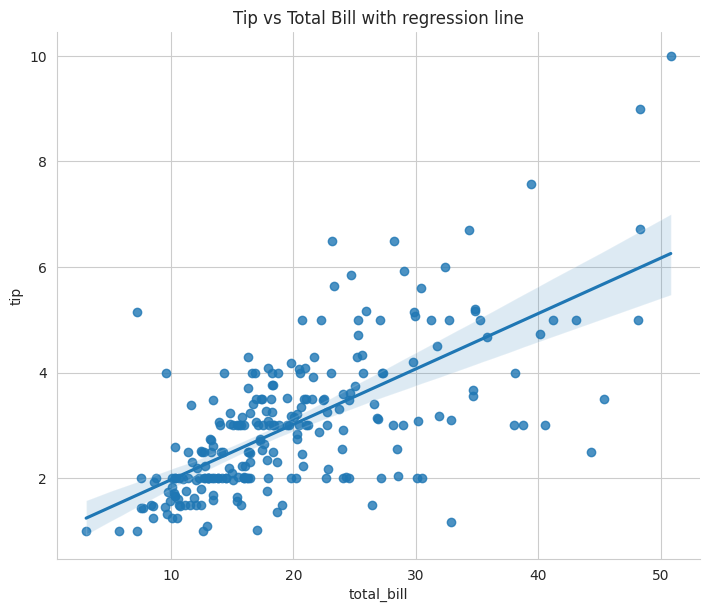

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Thu, 18 Sep 2025   Prob (F-statistic):           6.69e-34
Time:                        13:43:49   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.0

In [7]:
#ques 6
# Cell 6
sns.lmplot(x='total_bill', y='tip', data=tips, height=6, aspect=1.2)
plt.title("Tip vs Total Bill with regression line")
plt.show()
# Print regression summary via statsmodels
model = sm.OLS(tips['tip'], sm.add_constant(tips['total_bill'])).fit()
print(model.summary())



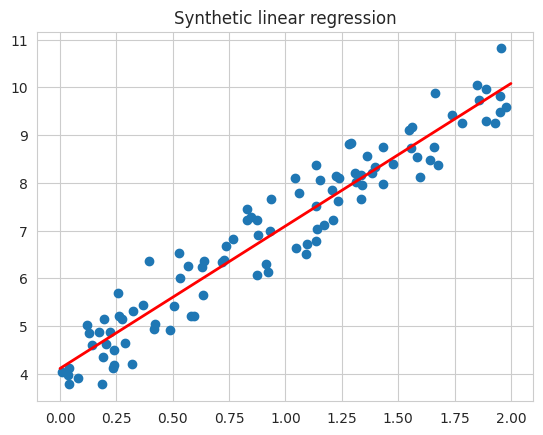

Coef: [2.98423376] Intercept: 4.111075538723615


In [8]:
#ques 7
np.random.seed(0)
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X[:,0] + np.random.randn(100) * 0.5
lr = LinearRegression().fit(X, y)
X_new = np.array([[0],[2]])
y_pred = lr.predict(X_new)
plt.scatter(X, y)
plt.plot(X_new, y_pred, "r-", linewidth=2)
plt.title("Synthetic linear regression")
plt.show()
print("Coef:", lr.coef_, "Intercept:", lr.intercept_)


In [9]:
#ques 8
# Train small model
lr = LinearRegression().fit(X, y)
# Save with pickle
with open("linear_model.pkl", "wb") as f:
    pickle.dump(lr, f)
# Load back
with open("linear_model.pkl", "rb") as f:
    loaded = pickle.load(f)
print("Loaded model coef:", loaded.coef_, "intercept:", loaded.intercept_)


Loaded model coef: [2.98423376] intercept: 4.111075538723615


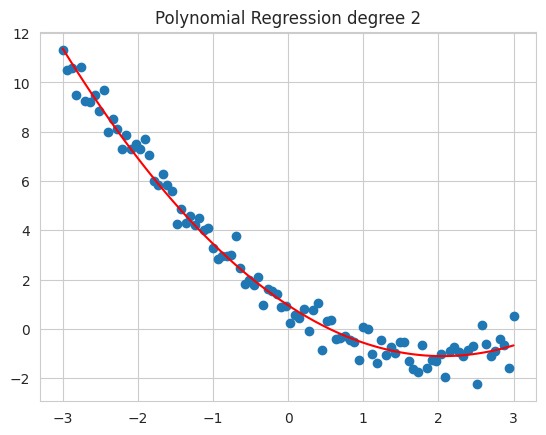

In [10]:
#ques 9
# Cell 9
X = np.linspace(-3,3,100).reshape(-1,1)
y = 1 - 2*X[:,0] + 0.5*X[:,0]**2 + np.random.randn(100)*0.5
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
lr = LinearRegression().fit(X_poly, y)
y_pred = lr.predict(X_poly)
plt.scatter(X, y)
plt.plot(X, y_pred, color='red')
plt.title("Polynomial Regression degree 2")
plt.show()



In [11]:
#ques 10
# Cell 10
np.random.seed(42)
X = np.random.rand(100,1)*10
y = 2.5 + 1.7*X[:,0] + np.random.randn(100)*2
lr = LinearRegression().fit(X, y)
print("Coef:", lr.coef_[0], "Intercept:", lr.intercept_)


Coef: 1.6080453545753934 Intercept: 2.930192315093498


In [12]:
#ques 11
X = np.random.rand(200,1)*3 - 1.5
y = 1 + 2*X[:,0] - 1.5*X[:,0]**2 + 0.5*X[:,0]**3 + np.random.randn(200)*0.5
degrees = [1,2,3,4,5]
for d in degrees:
    poly = PolynomialFeatures(d)
    Xp = poly.fit_transform(X)
    lr = LinearRegression().fit(Xp, y)
    pred = lr.predict(Xp)
    print(f"Degree {d}: R2 = {r2_score(y, pred):.4f}")

Degree 1: R2 = 0.8180
Degree 2: R2 = 0.9592
Degree 3: R2 = 0.9662
Degree 4: R2 = 0.9662
Degree 5: R2 = 0.9662


In [13]:
#ques 12
X = np.random.rand(150,2)
y = 1.5 + 2*X[:,0] - 3*X[:,1] + np.random.randn(150)*0.5
lr = LinearRegression().fit(X, y)
print("Coefficients:", lr.coef_)
print("Intercept:", lr.intercept_)
print("R-squared:", lr.score(X, y))

Coefficients: [ 1.99706758 -3.04843727]
Intercept: 1.6229516992402044
R-squared: 0.837420651636635


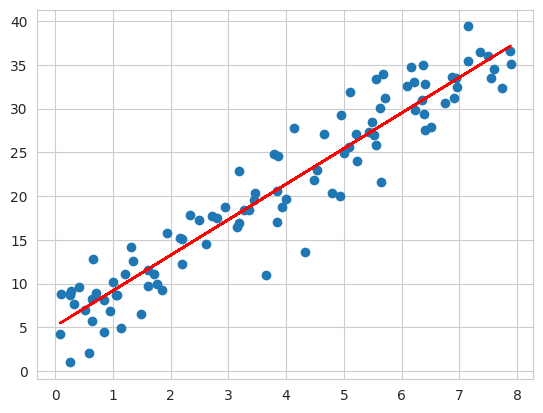

In [14]:
#ques 13
X = np.random.rand(100,1)*8
y = 5 + 4*X[:,0] + np.random.randn(100)*3
lr = LinearRegression().fit(X, y)
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color='red')
plt.show()

In [15]:
#ques 14
np.random.seed(0)
X1 = np.random.randn(200)
X2 = 0.9*X1 + np.random.randn(200)*0.1  # highly correlated with X1
X3 = np.random.randn(200)
df_vif = pd.DataFrame({'X1':X1,'X2':X2,'X3':X3})
# Add constant for VIF calculation
X_with_const = sm.add_constant(df_vif)
vif_data = pd.DataFrame()
vif_data['feature'] = X_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
print(vif_data)

  feature         VIF
0   const    1.030576
1      X1  101.622309
2      X2  101.439249
3      X3    1.038335


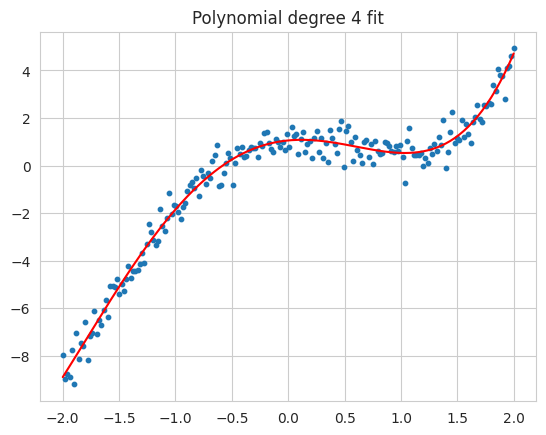

In [16]:
#ques 15
np.random.seed(1)
X = np.linspace(-2,2,200).reshape(-1,1)
y = 1 + 0.5*X[:,0] - 2*X[:,0]**2 + 0.7*X[:,0]**3 + 0.3*X[:,0]**4 + np.random.randn(200)*0.5
poly = PolynomialFeatures(degree=4)
Xp = poly.fit_transform(X)
lr = LinearRegression().fit(Xp, y)
yp = lr.predict(Xp)
plt.scatter(X, y, s=10)
plt.plot(X, yp, color='red')
plt.title("Polynomial degree 4 fit")
plt.show()

In [17]:
#ques 16
X = np.random.rand(300,4)
y = X.dot(np.array([1.2, -2.0, 0.5, 0.3])) + 0.7 + np.random.randn(300)*0.2
pipe = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)
pipe.fit(X_train, y_train)
print("R-squared on test:", pipe.score(X_test, y_test))


R-squared on test: 0.9076732994370367


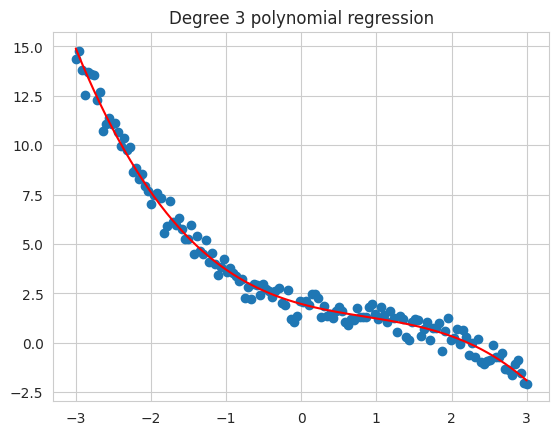

In [18]:
#ques 17
X = np.linspace(-3,3,150).reshape(-1,1)
y = 2 - X[:,0] + 0.5*X[:,0]**2 - 0.2*X[:,0]**3 + np.random.randn(150)*0.4
poly = PolynomialFeatures(3)
Xp = poly.fit_transform(X)
lr = LinearRegression().fit(Xp, y)
plt.scatter(X, y)
plt.plot(X, lr.predict(Xp), color='red')
plt.title("Degree 3 polynomial regression")
plt.show()

In [19]:
#ques 18
X = np.random.rand(500,5)
coefs = np.array([1.0,-2.0,0.5,0.3,1.5])
y = X.dot(coefs) + 0.5 + np.random.randn(500)*0.5
lr = LinearRegression().fit(X, y)
print("R2:", lr.score(X, y))
print("Coefficients:", lr.coef_)

R2: 0.7372019304064552
Coefficients: [ 0.9978383  -1.86835562  0.44193637  0.34071202  1.62138525]


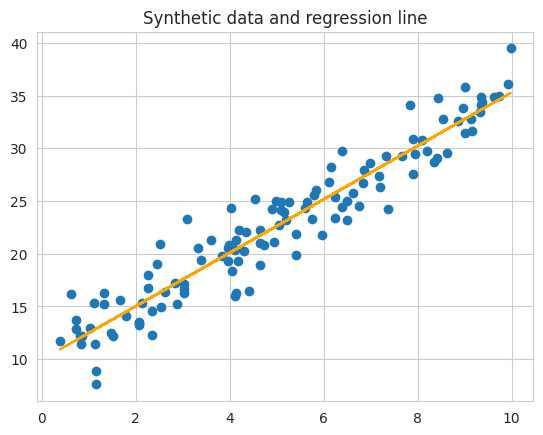

In [20]:
#ques 19
X = np.random.rand(120,1)*10
y = 10 + 2.5*X[:,0] + np.random.randn(120)*2
lr = LinearRegression().fit(X, y)
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color='orange')
plt.title("Synthetic data and regression line")
plt.show()

In [21]:
#ques 20
X = np.random.randn(200,3)
true_coefs = np.array([2.0, -1.0, 0.5])
y = X.dot(true_coefs) + 1.0 + np.random.randn(200)*0.3
lr = LinearRegression().fit(X, y)
print("R2:", lr.score(X, y))
print("Coefficients:", lr.coef_)

R2: 0.9813568176902283
Coefficients: [ 1.99336388 -1.0210455   0.50118805]


In [22]:
#ques 21
lr = LinearRegression().fit(X, y)  # from previous cell
joblib.dump(lr, "lr_joblib.pkl")
loaded = joblib.load("lr_joblib.pkl")
print("Loaded via joblib coef:", loaded.coef_)

Loaded via joblib coef: [ 1.99336388 -1.0210455   0.50118805]


In [23]:
#ques 22
tips = sns.load_dataset("tips")
# Use total_bill, sex, smoker, day as predictors for tip
features = ['total_bill', 'sex', 'smoker', 'day']
X = pd.get_dummies(tips[features], drop_first=True)
y = tips['tip']
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42)
lr = LinearRegression().fit(X_train, y_train)
print("R2:", lr.score(X_test, y_test))
print("Coefficients:")
print(pd.Series(lr.coef_, index=X.columns))

R2: 0.36389943138017555
Coefficients:
total_bill    0.112641
sex_Female   -0.032533
smoker_No     0.333369
day_Fri       0.086497
day_Sat      -0.119752
day_Sun      -0.045027
dtype: float64


In [24]:
#ques 23
X, y = make_regression(n_samples=300, n_features=8, noise=20, random_state=42)
lr = LinearRegression().fit(X, y)
ridge = Ridge(alpha=10).fit(X, y)
print("LR R2:", lr.score(X, y))
print("Ridge R2:", ridge.score(X, y))
print("LR coefs:", lr.coef_)
print("Ridge coefs:", ridge.coef_)

LR R2: 0.9823731495499642
Ridge R2: 0.9811767036076058
LR coefs: [59.90145266 96.47211508 58.41946608  7.31045546  8.15755555  6.34522899
 61.61316998 31.43458766]
Ridge coefs: [57.83988077 93.22099997 56.69426996  6.9748812   7.76868788  6.53221906
 59.06061632 29.61913414]


In [25]:
#ques 24
X, y = make_regression(n_samples=300, n_features=5, noise=15, random_state=42)
lr = LinearRegression()
scores = cross_val_score(lr, X, y, cv=5, scoring='r2')
print("5-fold R2 scores:", scores)
print("Mean R2:", scores.mean())

5-fold R2 scores: [0.98022246 0.98121923 0.98529843 0.97655497 0.97510972]
Mean R2: 0.9796809611347859


In [26]:
#ques 25
np.random.seed(0)
X = np.linspace(-2,2,200).reshape(-1,1)
y = 1 - 2*X[:,0] + 0.5*X[:,0]**2 + np.random.randn(200)*0.6
for d in range(1,6):
    poly = PolynomialFeatures(degree=d)
    Xp = poly.fit_transform(X)
    lr = LinearRegression().fit(Xp, y)
    print(f"Degree {d}, R2: {r2_score(y, lr.predict(Xp)):.4f}")

Degree 1, R2: 0.8799
Degree 2, R2: 0.9405
Degree 3, R2: 0.9420
Degree 4, R2: 0.9464
Degree 5, R2: 0.9473
